In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
train = pd.read_csv('../data/raw/train.csv')
test = pd.read_csv('../data/raw/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nFirst 5 rows:")
train.head()

Train shape: (577347, 12)
Test shape: (247435, 11)

First 5 rows:


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [2]:
# Basic info
print("=== Class Distribution ===")
print(train['class'].value_counts())
print("\n=== Missing Values ===")
print(train.isnull().sum())
print("\n=== Data Types ===")
print(train.dtypes)
print("\n=== Basic Statistics ===")
train.describe()

=== Class Distribution ===
class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

=== Missing Values ===
id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64

=== Data Types ===
id                     int64
alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type            str
galaxy_population        str
class                    str
dtype: object

=== Basic Statistics ===


,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


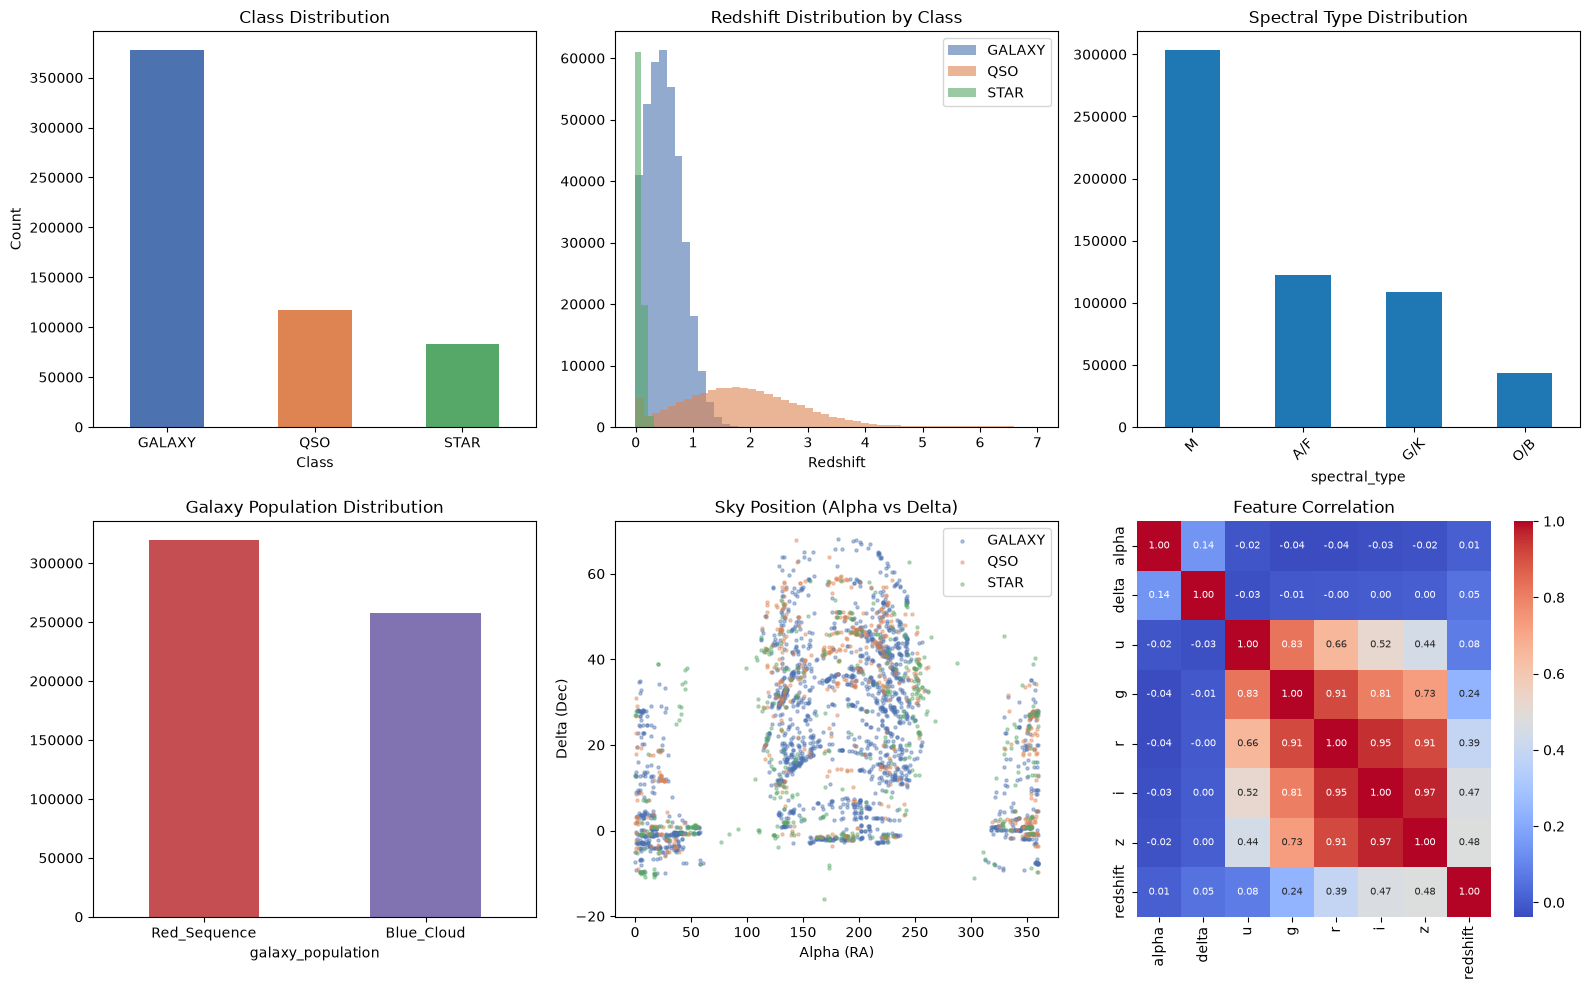

Charts saved!


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Class distribution
train['class'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#4C72B0','#DD8452','#55A868'])
axes[0,0].set_title('Class Distribution')
axes[0,0].set_xlabel('Class')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# 2. Redshift by class
for cls, color in zip(['GALAXY','QSO','STAR'], ['#4C72B0','#DD8452','#55A868']):
    subset = train[train['class']==cls]['redshift']
    axes[0,1].hist(subset, bins=50, alpha=0.6, label=cls, color=color)
axes[0,1].set_title('Redshift Distribution by Class')
axes[0,1].set_xlabel('Redshift')
axes[0,1].legend()

# 3. Spectral type distribution
train['spectral_type'].value_counts().plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title('Spectral Type Distribution')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Galaxy population
train['galaxy_population'].value_counts().plot(kind='bar', ax=axes[1,0], color=['#c44e52','#8172b2','#937860'])
axes[1,0].set_title('Galaxy Population Distribution')
axes[1,0].tick_params(axis='x', rotation=0)

# 5. Alpha vs Delta scatter (sample)
sample = train.sample(3000, random_state=42)
colors = {'GALAXY':'#4C72B0','QSO':'#DD8452','STAR':'#55A868'}
for cls in ['GALAXY','QSO','STAR']:
    s = sample[sample['class']==cls]
    axes[1,1].scatter(s['alpha'], s['delta'], c=colors[cls], label=cls, alpha=0.4, s=5)
axes[1,1].set_title('Sky Position (Alpha vs Delta)')
axes[1,1].set_xlabel('Alpha (RA)')
axes[1,1].set_ylabel('Delta (Dec)')
axes[1,1].legend()

# 6. Correlation heatmap
num_cols = ['alpha','delta','u','g','r','i','z','redshift']
corr = train[num_cols].corr()
sns.heatmap(corr, ax=axes[1,2], annot=True, fmt='.2f', cmap='coolwarm', annot_kws={"size":7})
axes[1,2].set_title('Feature Correlation')

plt.tight_layout()
plt.savefig('../eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved!")

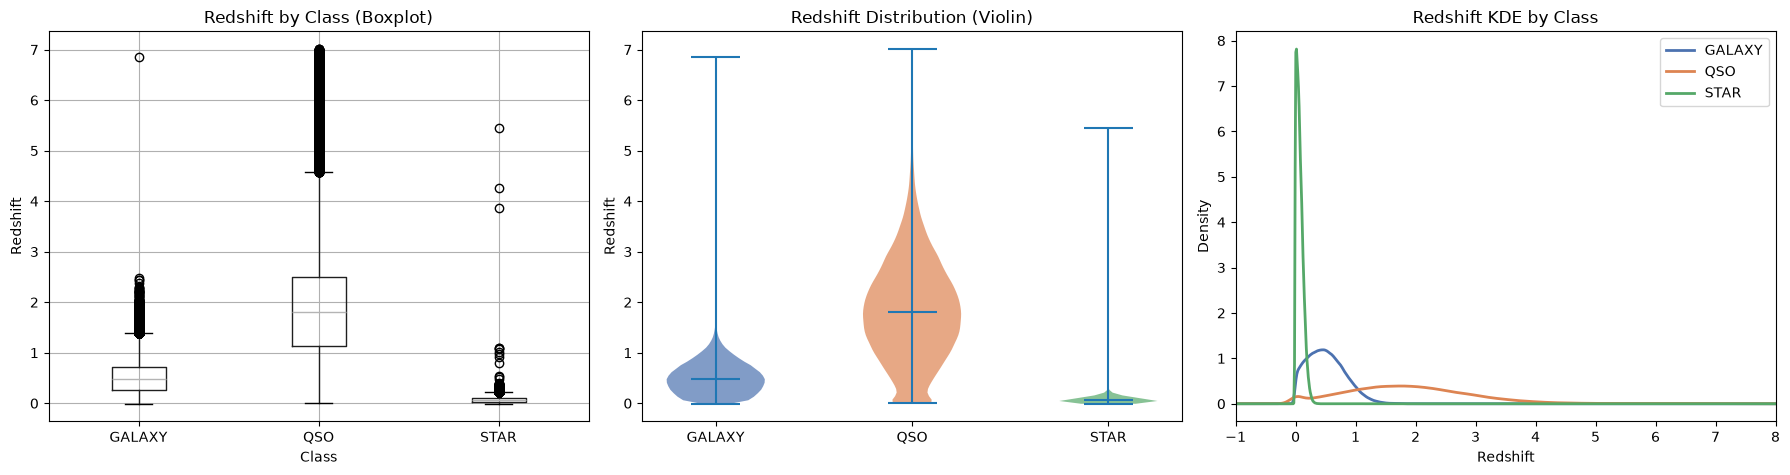

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box plot
train.boxplot(column='redshift', by='class', ax=axes[0])
axes[0].set_title('Redshift by Class (Boxplot)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Redshift')
plt.sca(axes[0])
plt.xticks(rotation=0)

# Violin plot
import matplotlib.patches as mpatches
classes = ['GALAXY', 'QSO', 'STAR']
colors_v = ['#4C72B0', '#DD8452', '#55A868']
data_v = [train[train['class']==c]['redshift'].values for c in classes]
parts = axes[1].violinplot(data_v, positions=[1,2,3], showmedians=True)
for pc, color in zip(parts['bodies'], colors_v):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
axes[1].set_xticks([1,2,3])
axes[1].set_xticklabels(classes)
axes[1].set_title('Redshift Distribution (Violin)')
axes[1].set_ylabel('Redshift')

# KDE plot
for cls, color in zip(classes, colors_v):
    subset = train[train['class']==cls]['redshift']
    subset.plot.kde(ax=axes[2], label=cls, color=color, linewidth=2)
axes[2].set_title('Redshift KDE by Class')
axes[2].set_xlabel('Redshift')
axes[2].legend()
axes[2].set_xlim(-1, 8)

plt.suptitle('')
plt.tight_layout()
plt.savefig('../eda_redshift_deep.png', dpi=150, bbox_inches='tight')
plt.show()

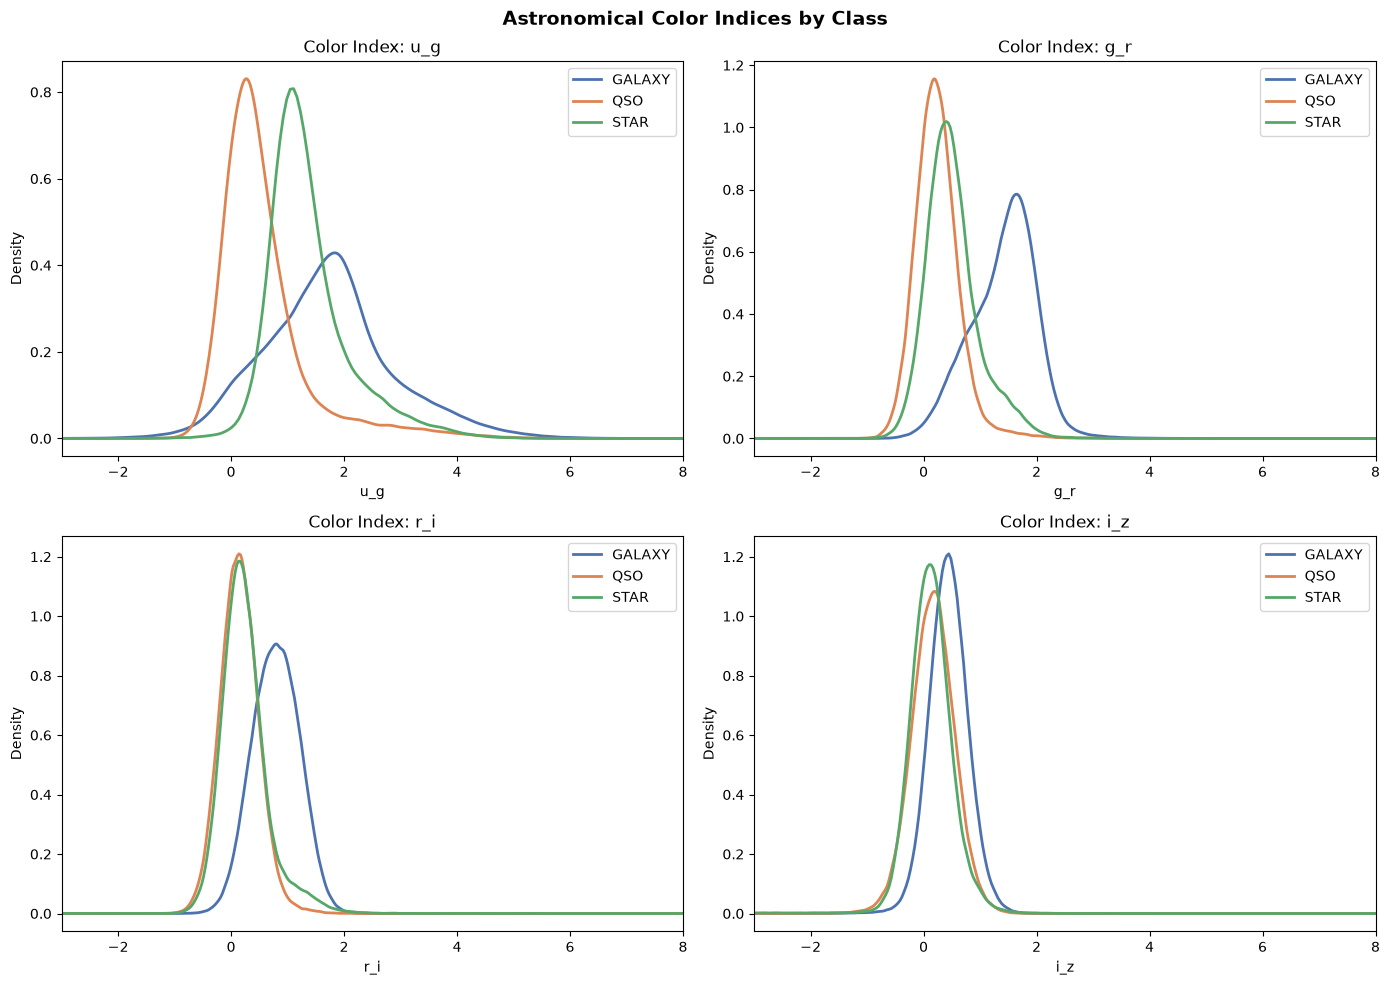

In [5]:
# Color indices (astronomy key features)
train_eda = train.copy()
train_eda['u_g'] = train_eda['u'] - train_eda['g']
train_eda['g_r'] = train_eda['g'] - train_eda['r']
train_eda['r_i'] = train_eda['r'] - train_eda['i']
train_eda['i_z'] = train_eda['i'] - train_eda['z']

color_cols = ['u_g', 'g_r', 'r_i', 'i_z']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(color_cols):
    for cls, color in zip(classes, colors_v):
        subset = train_eda[train_eda['class']==cls][col]
        subset.plot.kde(ax=axes[idx], label=cls, color=color, linewidth=2)
    axes[idx].set_title(f'Color Index: {col}')
    axes[idx].set_xlabel(col)
    axes[idx].legend()
    axes[idx].set_xlim(-3, 8)

plt.suptitle('Astronomical Color Indices by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../eda_color_indices.png', dpi=150, bbox_inches='tight')
plt.show()

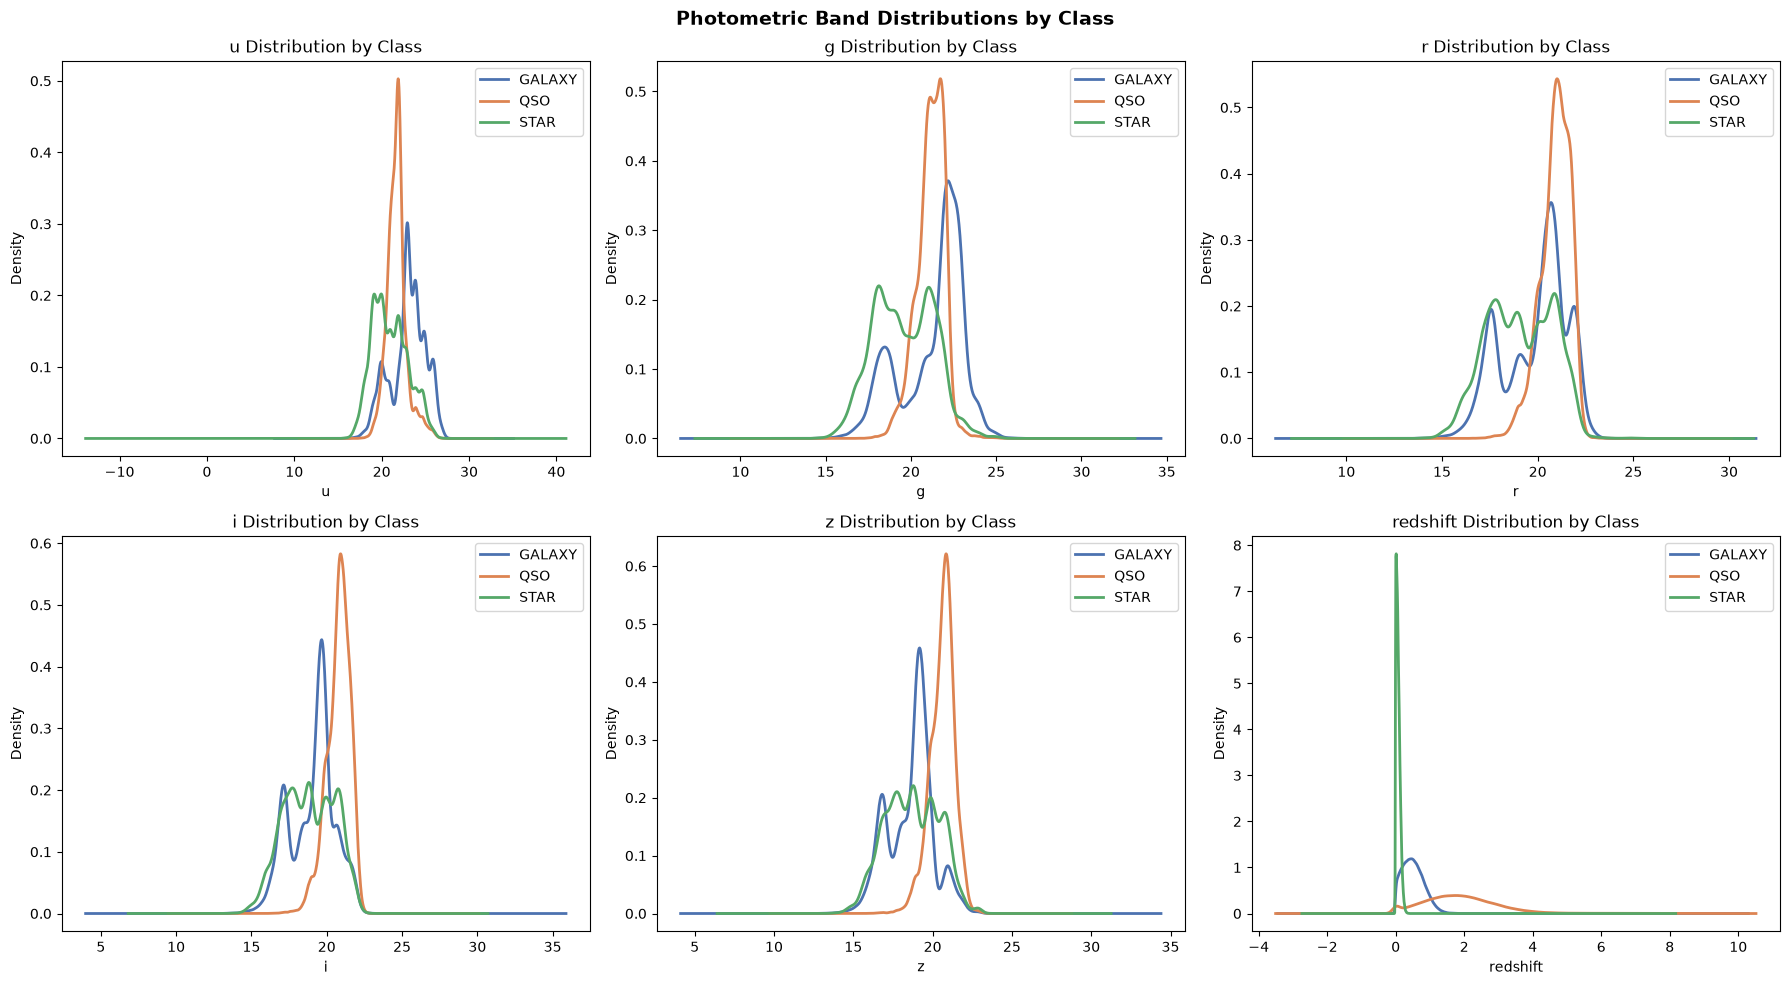

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

num_features = ['u', 'g', 'r', 'i', 'z', 'redshift']

for idx, feat in enumerate(num_features):
    ax = axes[idx//3][idx%3]
    for cls, color in zip(classes, colors_v):
        subset = train_eda[train_eda['class']==cls][feat]
        subset.plot.kde(ax=ax, label=cls, color=color, linewidth=2)
    ax.set_title(f'{feat} Distribution by Class')
    ax.set_xlabel(feat)
    ax.legend()

plt.suptitle('Photometric Band Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../eda_bands.png', dpi=150, bbox_inches='tight')
plt.show()

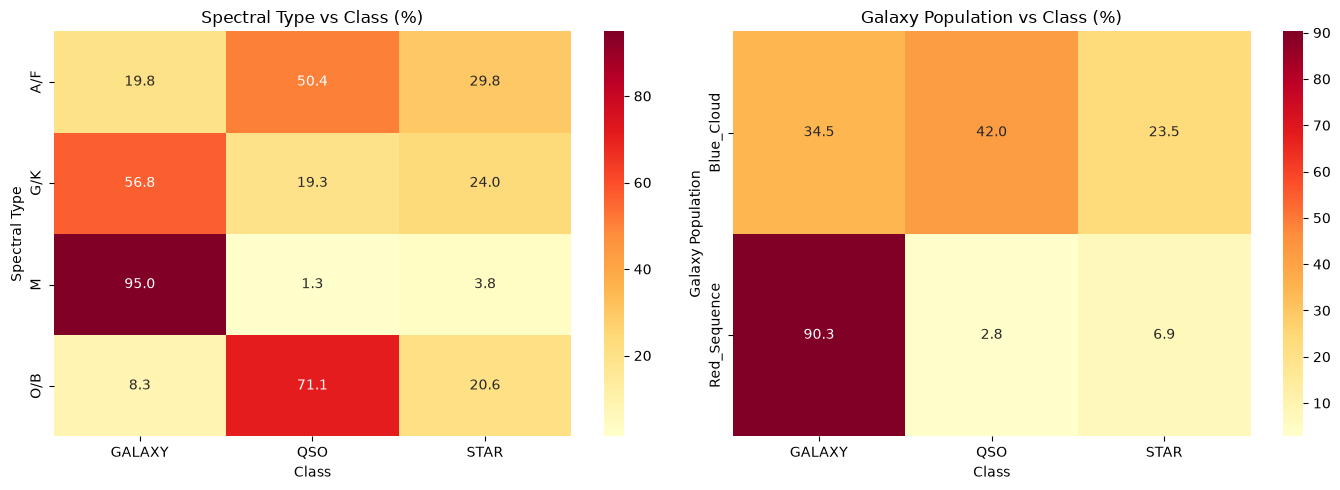

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spectral type vs Class heatmap
ct1 = pd.crosstab(train['spectral_type'], train['class'], normalize='index') * 100
sns.heatmap(ct1, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Spectral Type vs Class (%)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Spectral Type')

# Galaxy population vs Class heatmap
ct2 = pd.crosstab(train['galaxy_population'], train['class'], normalize='index') * 100
sns.heatmap(ct2, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Galaxy Population vs Class (%)')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Galaxy Population')

plt.tight_layout()
plt.savefig('../eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print("="*60)
print("EDA SUMMARY")
print("="*60)

print("\nDataset Size:")
print(f"  Train: {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"  Test:  {test.shape[0]:,} rows × {test.shape[1]} columns")

print("\nClass Distribution:")
for cls, cnt in train['class'].value_counts().items():
    pct = cnt/len(train)*100
    print(f"  {cls:<8}: {cnt:>7,} ({pct:.1f}%)")

print("\nRedshift Statistics by Class:")
print(train.groupby('class')['redshift'].agg(['mean','std','min','max']).round(3))

print("\nSpectral Type vs Class:")
print(pd.crosstab(train['spectral_type'], train['class']))

print("\nGalaxy Population vs Class:")
print(pd.crosstab(train['galaxy_population'], train['class']))

print("\nMissing Values: NONE")
print("\nKey Insights:")
print("  1. Redshift is the strongest separator (STARs ≈ 0, QSOs > 1)")
print("  2. Color indices (u-g, g-r) differ significantly across classes")
print("  3. Classes are imbalanced → Balanced Accuracy metric used")
print("  4. Spectral type M dominates → mostly galaxies")
print("  5. Sky position (alpha/delta) shows no class separation")

EDA SUMMARY

Dataset Size:
  Train: 577,347 rows × 12 columns
  Test:  247,435 rows × 11 columns

Class Distribution:
  GALAXY  : 377,480 (65.4%)
  QSO     : 117,143 (20.3%)
  STAR    :  82,724 (14.3%)

Redshift Statistics by Class:
         mean    std   min    max
class                            
GALAXY  0.509  0.309 -0.01  6.860
QSO     1.876  1.070  0.00  7.011
STAR    0.068  0.064 -0.01  5.445

Spectral Type vs Class:
class          GALAXY    QSO   STAR
spectral_type                      
A/F             24240  61514  36368
G/K             61627  20921  25998
M              288023   3889  11411
O/B              3590  30819   8947

Galaxy Population vs Class:
class              GALAXY     QSO   STAR
galaxy_population                       
Blue_Cloud          88962  108274  60546
Red_Sequence       288518    8869  22178

Missing Values: NONE

Key Insights:
  1. Redshift is the strongest separator (STARs ≈ 0, QSOs > 1)
  2. Color indices (u-g, g-r) differ significantly across class